# Movie Box Office Prediction
Can we predict whether a movie will be a hit based on its budget, genre, and cast?
This project explores 5000 movies from TMDB to find patterns in what makes a successful film.

In [2]:
# ---- Imports ----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---- Load Data -----
df_movies = pd.read_csv("data/tmdb_5000_movies.csv")
df_credits = pd.read_csv("data/tmdb_5000_credits.csv")

#----First Look----
print("Shape:", df_movies.shape)
print("Shape:", df_credits.shape)
print("\nColumns:\n", df_movies.columns.tolist())
print("\nColumns:\n", df_credits.columns.tolist())
print("\nFirst 5 rows:", df_movies.head())
print("\nFirst 5 rows:", df_credits.head())

Shape: (4803, 20)
Shape: (4803, 4)

Columns:
 ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Columns:
 ['movie_id', 'title', 'cast', 'crew']

First 5 rows:       budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.

## Merging Datasets
Combining movies and credits data on the movie title

In [3]:
# Merge both datasets on title
df = df_movies.merge(df_credits, on = "title")

# Checking
print("Merged shape:", df.shape)
print("Columns:", df.columns.tolist())

Merged shape: (4809, 23)
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'movie_id', 'cast', 'crew']


## Data Overview & Cleaning
Before any analysis we need to understand what we have and fix any issues. 

In [4]:
#Summary of all columns and their types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   str    
 2   homepage              1713 non-null   str    
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   str    
 5   original_language     4809 non-null   str    
 6   original_title        4809 non-null   str    
 7   overview              4806 non-null   str    
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   str    
 10  production_countries  4809 non-null   str    
 11  release_date          4808 non-null   str    
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   str    
 15  status                4809 non-n

In [5]:
#Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

Duplicate rows: 0


## Data Cleaning
Dropping unnecessary columns and handling missing values

In [6]:
# Drop columns we don't need
df = df.drop(columns = ["homepage", "tagline", "id", "movie_id", "original_title", "spoken_languages", "production_countries", "status", "original_language"])

# Dop rows with missing values
df = df.dropna()

# Confirm
print("Shape after cleaning:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

Shape after cleaning: (4805, 14)
Missing values remaining: 0


## Extract names from columns
The genre column and director column have messy JSON text, so we need to extract the information from them


In [7]:
import ast

# Fix the genres column
def extract_names(text):
    try:
        # Convert the text strign INTO a real Python list
        items = ast.literal_eval(text)
        # Grab just the "name" from each item 
        return[item["name"] for item in items]
    except:
        return [] # If anything goes wrong, return an empty list

# Extract clean lists from JSON columns
df["genres"] = df["genres"].apply(extract_names)
df["keywords"] = df["keywords"].apply(extract_names)

# Check
print(df["genres"].head())

0    [Action, Adventure, Fantasy, Science Fiction]
1                     [Adventure, Fantasy, Action]
2                       [Action, Adventure, Crime]
3                 [Action, Crime, Drama, Thriller]
4             [Action, Adventure, Science Fiction]
Name: genres, dtype: object


In [8]:
def extract_director(text):
    try:
        crew = ast.literal_eval(text)
        for member in crew:
            if member["job"] == "Director":
                return member["name"]
    except:
        return None

# Apply it
df["director"] = df["crew"].apply(extract_director)

# We can now drop the raw cast and crew columns
df = df.drop(columns = ["cast", "crew"])

# Check if it worked
print(df["director"].head())
print("\nMissing directors:", df["director"].isnull().sum())

0        James Cameron
1       Gore Verbinski
2           Sam Mendes
3    Christopher Nolan
4       Andrew Stanton
Name: director, dtype: str

Missing directors: 29


## Extracting the year from the release date column

In [9]:
# Convert release_date to datetime and extract year
df["release_date"] = pd.to_datetime(df["release_date"])
df["year"] = df["release_date"].dt.year

# Drop the original release_date column
df = df.drop(columns=["release_date"])

# Check it worked
print(df["year"].head())
print("\nYear range:", df["year"].min(), "to", df["year"].max())

0    2009
1    2007
2    2015
3    2012
4    2012
Name: year, dtype: int32

Year range: 1916 to 2017


In [10]:
# Create a "hit" column - 1 if revenue is more than double the budget, 0 if not
df["hit"] = (df["revenue"] > df["budget"] * 2).astype(int)

# Check the balance
print("\nHit distribution:")
print(df["hit"].value_counts())


Hit distribution:
hit
0    2852
1    1953
Name: count, dtype: int64


## Exploratory Data Analysis
Before buildnig our model, let's explore the data to understand what patterns exist.

###  Distribution of Revenue

Text(0, 0.5, 'Count')

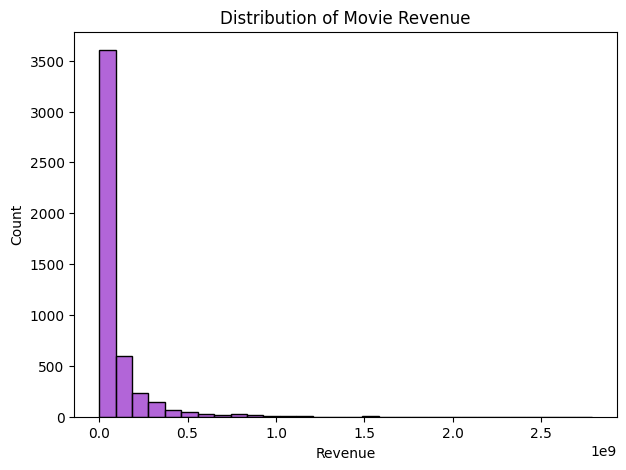

In [23]:
plt.figure(figsize = (7, 5))
sns.histplot(df["revenue"], bins = 30, color = 'darkorchid')
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")

### Observation
Revenue is highly right skewed with a large spike near zero, suggesting most movies make relatively little money. The long tail exxtending to 2.5 billion represents rare blockbusters - films that make extraordinary revenue compared to the average movie. This confirms that massive box office success is the exception, not the rule.

### Distribution of Budget

Text(0, 0.5, 'Count')

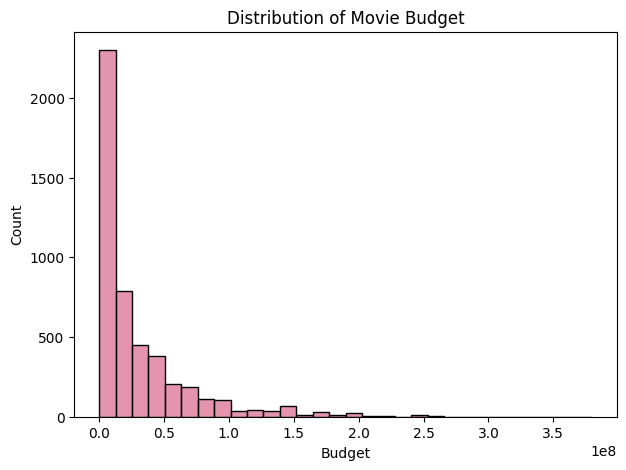

In [22]:
plt.figure(figsize = (7, 5))
sns.histplot(df["budget"], bins = 30, color = 'palevioletred')
plt.title("Distribution of Movie Budget")
plt.xlabel("Budget")
plt.ylabel("Count")



### Budget vs Revenue

Text(0, 0.5, 'Movie Revenue')

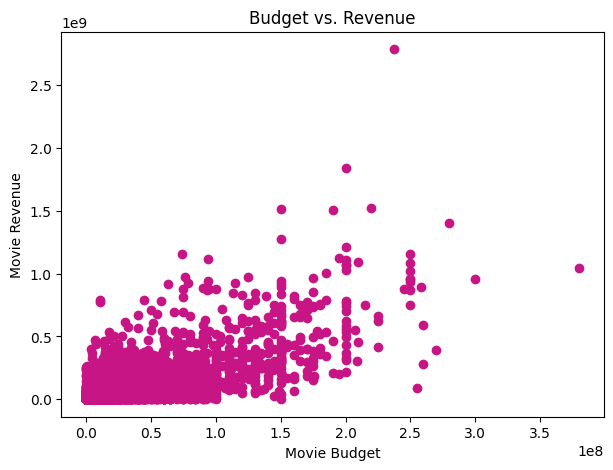

In [25]:
plt.figure(figsize = (7, 5))
plt.scatter(df["budget"], df["revenue"], c = 'mediumvioletred')
plt.title("Budget vs. Revenue")
plt.xlabel("Movie Budget")
plt.ylabel("Movie Revenue")

### Observations
Budget follows a similar right-skewed distribution to revenue, most movies are low budget with a few extremely expensive outliers. The scatter plot reveals a weak positive relationship between budget and revenue, suggesting higher budgets tend to produce higher revenue but with big variance. A $150M movie could make anywhere from almost nothing to over a billion, confirming that budget alone doesn't guarantee success. The extreme outlier near $2.7B revenue is Avatar, the highest grossing film in the dataset. 

### Top genres by number of hits

C:\Users\Meghana\AppData\Local\Temp\ipykernel_20488\396673093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = genre_hits.values, y = genre_hits.index, palette='crest')


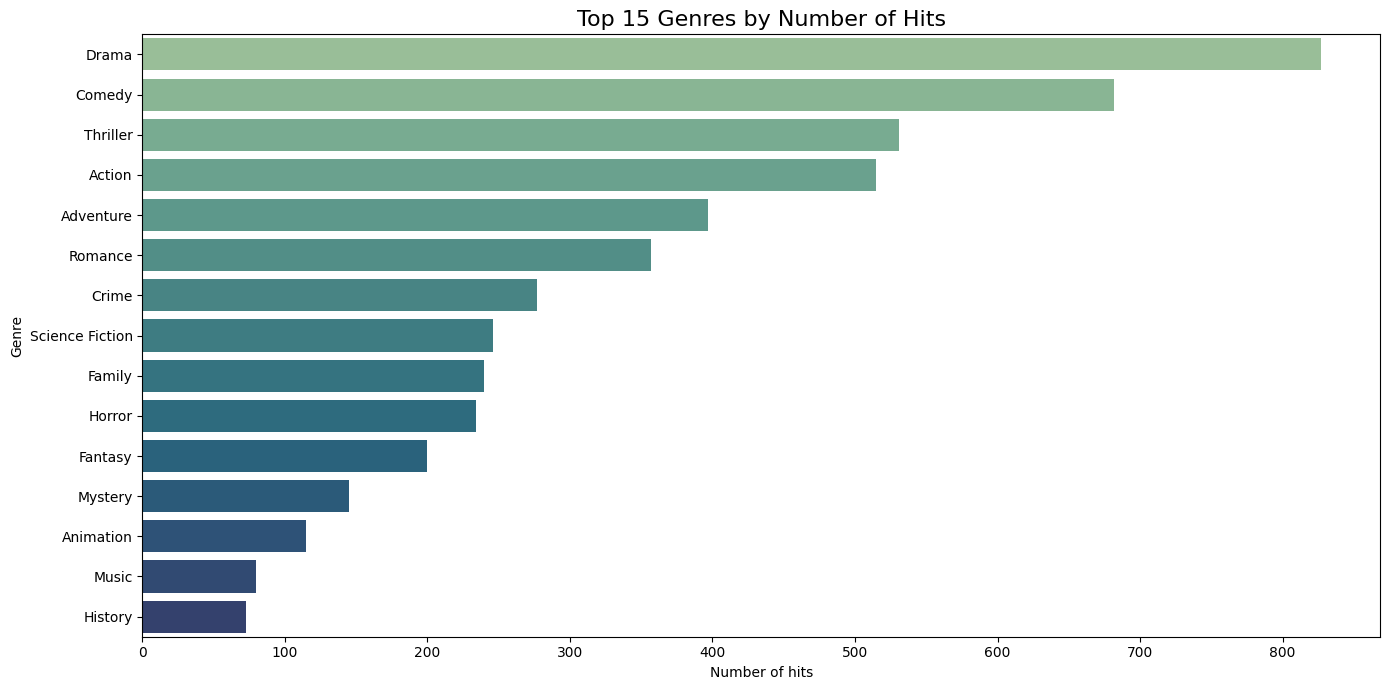

In [32]:
# Seperate genre list
df_exploded = df.explode("genres")
# Filter for only hits
df_hits = df_exploded[df_exploded["hit"] == 1]
# Group by genre and count
genre_hits = df_hits.groupby("genres")["hit"].count().sort_values(ascending = False).head(15)

# Plot
plt.figure(figsize = (14,7))
sns.barplot(x = genre_hits.values, y = genre_hits.index, palette='crest')
plt.title("Top 15 Genres by Number of Hits", fontsize = 16)
plt.xlabel("Number of hits")
plt.ylabel("Genre")
plt.tight_layout()

### Observation
Drama dominates with over 800 hits, which makes sense as it's one of the broadest genres, almost any story can be classified as a drama. The top four genres (drama, comedy, thriller, and action) share universal appeal across wide audiences. History and music rank lowest not because they underperform, but becuase fewer films are made in those genres. Animation's low count similarly reflects limited production volume rather than poor performance, animated hits like Pixar films are rare but massive. 